In [1]:
from ase.io import read
from ase.io import Trajectory
import matplotlib.pyplot as plt

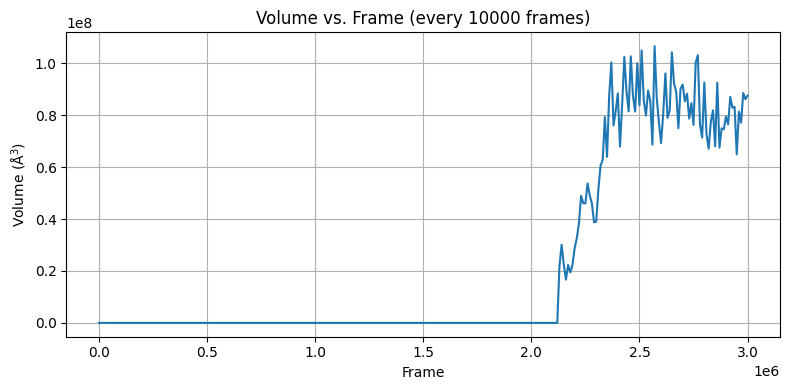

In [5]:
traj_path_vol = "/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/ablation_diffusivity/20ns_solvent_0_1M/md_omol_naotf_dme_s1p1_omol/md_omol_naotf_dme_s1p1_omol.traj"

frame_step = 10000  # Do every 10000*10fs frames

with Trajectory(traj_path_vol, mode='r') as traj:
    n_frames = len(traj)
    frame_indices = range(0, n_frames, frame_step)
    vols = [traj[i].get_volume() for i in frame_indices]

plt.figure(figsize=(8,4))
plt.plot([i+1 for i in frame_indices], vols)
plt.xlabel("Frame")
plt.ylabel("Volume ($\\mathrm{\\AA}^3$)")
plt.title("Volume vs. Frame (every 10000 frames)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8,4))
plt.plot([i+1 for i in frame_indices], vols)
plt.xlabel("Frame")
plt.ylabel("Volume ($\\mathrm{\\AA}^3$)")
plt.title("Volume vs. Frame (every 10000 frames)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Load the trajectory file
traj_path = "/global/homes/y/yuejian/project/MLFF-distill/10ns_trajs_student_293k/naotf_dme.traj"

with Trajectory(traj_path, mode='r') as traj:
    # Load the first 20000 frames (or fewer if not enough)
    frame_count = len(traj)
    num_to_load = min(40000, frame_count)
    print(f"Number of frames in trajectory: {frame_count}. Loading first {num_to_load} frames.")
    frames = [traj[i] for i in range(num_to_load)]
    frames = frames[10000:]



Number of frames in trajectory: 1374632. Loading first 40000 frames.


Mean temperature: 297.86 K


ValueError: x and y must have same first dimension, but have shapes (40000,) and (30000,)

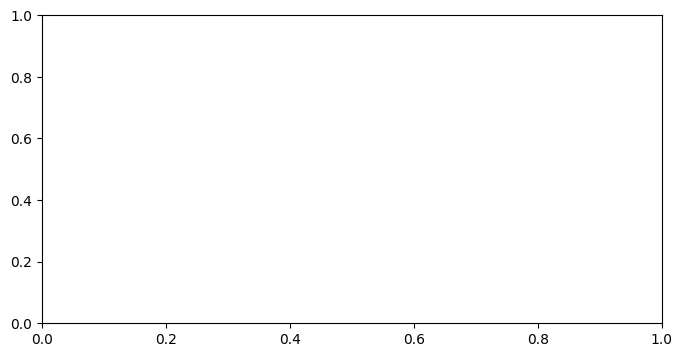

In [23]:
# Compute temperature for each frame and show mean
temperatures = [atoms.get_temperature() for atoms in frames]
mean_temperature = sum(temperatures) / len(temperatures)
print(f"Mean temperature: {mean_temperature:.2f} K")

plt.figure(figsize=(8,4))
plt.plot(range(1, num_to_load + 1), temperatures)
plt.xlabel("Frame")
plt.ylabel("Temperature (K)")
plt.title("Temperature vs. Frame")
plt.grid(True)
plt.tight_layout()
plt.show()